In [1]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import polars as pl  # import polars to import data
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os
import time
from copy import copy
from skimage.filters import gaussian
import xarray as xr

from pyS3M import IOFunctions

IO = IOFunctions.IO_Functions()

from pyS3M import Multicolour_Simulation_Functions

MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

from pyS3M import PSFFunctions

PSF = PSFFunctions.PSF_Functions()

from pyS3M import PlottingBase

plotter = PlottingBase.PublicationPlotter()

from src import AnalysisFunctions

AF = AnalysisFunctions.Analysis_Functions()

import colour

from colour_demosaicing import (
    ROOT_RESOURCES_EXAMPLES,
    demosaicing_CFA_Bayer_bilinear,
    demosaicing_CFA_Bayer_Malvar2004,
    demosaicing_CFA_Bayer_Menon2007,
    mosaicing_CFA_Bayer,
)

from pyS3M import sCMOSFunctions

sCMOS = sCMOSFunctions.sCMOS_Functions()

In [2]:
data_folder = "/home/jbeckwith/Documents/Dropbox/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Data/Salix/CS505CU_Calibration"
gain = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
offset = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
variance = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
readnoise = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
rqe = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))

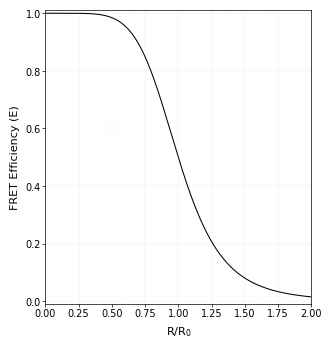

In [3]:
x = np.linspace(0, 2, 10000)
E = 1 / (1 + np.power(x, 6))

fig, axs = plotter.one_column_plot()

axs = plotter.line_plot(
    axs=axs, x=x, y=E, xaxislabel=r"R/R$_0$", yaxislabel="FRET Efficiency (E)"
)

axs.set_ylim([-0.01, 1.01])
plt.tight_layout()
folder = "/home/jbeckwith/Documents/Dropbox/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Group Meeting/20241104/fig/multicolour_camera/FRET"
# plt.savefig(os.path.join(folder, 'FRET_Efficiency_E.svg'), format='svg', dpi=600)

In [4]:
folder = "/home/jbeckwith/Documents/Dropbox/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Data/Simulation/20241028/data"
dynamics = pl.read_csv(os.path.join(folder, "Langevin_Sim.csv"))

In [5]:
time = dynamics["time"].to_numpy()
E = dynamics["x"].to_numpy()

In [6]:
time = time / (time[-1] / 20)

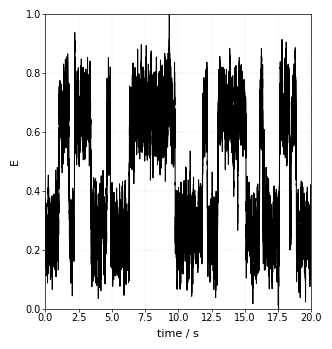

In [7]:
fig, axs = plotter.one_column_plot()

axs = plotter.line_plot(axs=axs, x=time, y=E, xaxislabel="time / s", yaxislabel="E")

plt.tight_layout()
folder = "/home/jbeckwith/Documents/Dropbox/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Group Meeting/20241104/fig/multicolour_camera/FRET"
# plt.savefig(os.path.join(folder, 'Example_Trace.svg'), format='svg', dpi=600)

In [8]:
t_tosim = np.arange(0, time[-1] + 0.05, 0.05)
E_tosim = np.interp(x=t_tosim, xp=time, fp=E)

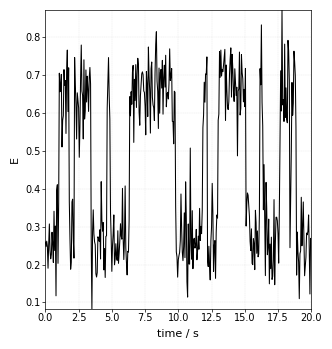

In [9]:
fig, axs = plotter.one_column_plot()

axs = plotter.line_plot(
    axs=axs, x=t_tosim, y=E_tosim, xaxislabel="time / s", yaxislabel="E"
)

plt.tight_layout()
folder = "/home/jbeckwith/Documents/Dropbox/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Group Meeting/20241104/fig/multicolour_camera/FRET"
# plt.savefig(os.path.join(folder, 'Trace_SeenbyCamera.svg'), format='svg', dpi=600)

In [19]:
image_size = 18

from Camera_QE import getpixelefficiency

gpe = getpixelefficiency.GPE()
R, G, B, wavelength = gpe.getpixelefficiency("Camera_QE/CS505CU_QE.csv")
RGB = np.vstack([R, G, B]).T
filters = np.ones_like(wavelength)
masks = MSF.MF.get_masks(MSF.mosaic_unit, image_size, image_size)
masks_3d = np.dstack([masks["maskR"], masks["maskG"], masks["maskB"]])
wavelength = wavelength
absolute_QYs = np.vstack([B, G, R])
camera_calibration = {}
camera_calibration["gain"] = gain[:image_size, :image_size]
camera_calibration["offset"] = offset[:image_size, :image_size]
camera_calibration["variance"] = variance[:image_size, :image_size]
camera_calibration["readnoise"] = readnoise[:image_size, :image_size]
camera_calibration["rqe"] = rqe[:image_size, :image_size]
NA = 1.49
pixel_size = 69
image_stack = np.zeros([image_size, image_size, len(t_tosim)])

In [20]:
n_photon = 1000

In [21]:
fret_pair = ["Cy3", "Cy5"]
fret_QYs = np.array([0.15, 0.27])
camera_string = "CS505CU"
filter_string = "nofilters"
fret_spectral_model = AF.gen_E_lookuptable(
    fret_pair, fret_QYs, RGB, wavelength, filters, camera_string, filter_string
)

In [22]:
fret_pair_0 = [x for x in AF.dye_filenames if fret_pair[0] in x]
fret_pair_1 = [x for x in AF.dye_filenames if fret_pair[1] in x]
if "ATTO" not in fret_pair[0]:
    separator = ","
    skip_rows = 0
else:
    separator = "\t"
    skip_rows = 1
data_F0 = pl.read_csv(
    os.path.join(AF.dye_folder, fret_pair_0[0]),
    separator=separator,
    skip_rows=skip_rows,
)
F0_wl = data_F0[:, 0].to_numpy()
F0_em = np.multiply(
    filters,
    np.interp(x=wavelength, xp=F0_wl, fp=data_F0[:, 1].to_numpy(), left=0, right=0),
)
F0_em = F0_em / np.trapz(x=wavelength, y=F0_em)
if "ATTO" not in fret_pair[1]:
    separator = ","
    skip_rows = 0
else:
    separator = "\t"
    skip_rows = 1
data_F1 = pl.read_csv(
    os.path.join(AF.dye_folder, fret_pair_1[0]),
    separator=separator,
    skip_rows=skip_rows,
)
F1_wl = data_F1[:, 0].to_numpy()
F1_em = np.multiply(
    filters,
    np.interp(x=wavelength, xp=F1_wl, fp=data_F1[:, 1].to_numpy(), left=0, right=0),
)
F1_em = F1_em / np.trapz(x=wavelength, y=F1_em)

In [23]:
for i in np.arange(len(t_tosim)):
    E = E_tosim[i]
    dyes = np.zeros([1, len(wavelength)])
    spectrum = ((F1_em * fret_QYs[1]) * E) + ((F0_em * fret_QYs[0]) * (1 - E))
    dyes[0, :] = spectrum / sum(spectrum)

    average_emission_wavelength = np.trapz(
        y=wavelength * (dyes.T / np.trapz(x=wavelength, y=dyes)).T, x=wavelength
    )
    sigma_PSF = PSF.sigma_PSF(average_emission_wavelength, NA)[0]

    x0y0 = {}
    max = pixel_size * image_size
    x0y0["dye"] = np.array([[max / 2], [max / 2]])
    n_photons = {}
    n_photons["dye"] = n_photon
    _, bayer_image = MSF.gen_camera_images(
        camera_calibration,
        wavelength,
        absolute_QYs,
        dyes,
        n_photons,
        x0y0,
        background_photons=0,
        NA=NA,
        pixel_size=pixel_size,
    )
    image_stack[:, :, i] = bayer_image

In [24]:
IO.write_tiff(
    image_stack,
    "/home/jbeckwith/Documents/Dropbox/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Group Meeting/20241104/fig/multicolour_camera/FRET/FRET_test.tiff",
)

In [16]:
E_fit = np.zeros_like(E_tosim)
Espace = np.linspace(0, 1, 101)
for i in np.arange(len(t_tosim)):
    photoelectron_data = np.divide(
        np.divide(
            np.subtract(image_stack[:, :, i], camera_calibration["offset"]),
            camera_calibration["gain"],
        ),
        camera_calibration["rqe"],
    )

    xc_ig, yc_ig = np.unravel_index(
        np.argmax(
            sCMOS.var_weighted_uniform_filter(
                photoelectron_data, camera_calibration["variance"], 4
            )
        ),
        photoelectron_data.shape,
    )
    A = np.sum((photoelectron_data))
    sigma = 3
    b = 0
    erd = copy(photoelectron_data)
    erd[erd < 0] = 0
    erd = erd + 1
    error_map = np.add(erd, np.square(camera_calibration["readnoise"]))
    weights_map = np.power(error_map, -2)

    initial_guess = np.array([xc_ig, yc_ig, A, sigma, b, 0.5])
    result = AF.FRET_fit(
        photoelectron_data,
        initial_guess,
        masks=masks_3d,
        weights=weights_map,
        fret_spectral_model=fret_spectral_model,
        Espace=Espace,
        display=False,
    )
    E_fit[i] = result.x[-1]

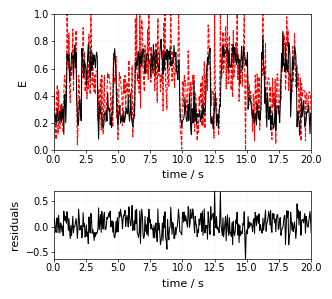

In [17]:
fig, axs = plotter.one_column_plot(npanels=2, ratios=[1, 0.5], height=3)

axs[0] = plotter.line_plot(
    axs=axs[0],
    x=t_tosim,
    y=E_fit,
    ls="--",
    color="red",
    yaxislabel="E",
    xaxislabel="time / s",
)
axs[0] = plotter.line_plot(
    axs=axs[0],
    x=t_tosim,
    y=E_tosim,
    color="black",
    yaxislabel="E",
    xaxislabel="time / s",
)

axs[0].set_ylim([0, 1])

axs[1] = plotter.line_plot(
    axs=axs[1],
    x=t_tosim,
    y=E_fit - E_tosim,
    color="black",
    yaxislabel="residuals",
    xaxislabel="time / s",
)

plt.tight_layout()
folder = "/home/jbeckwith/Documents/Dropbox/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Group Meeting/20241104/fig/multicolour_camera/FRET"
plt.savefig(
    os.path.join(folder, "Trace_DeducedbyCamera_tryingnnew.svg"), format="svg", dpi=600
)
plt.show()

61.581284555


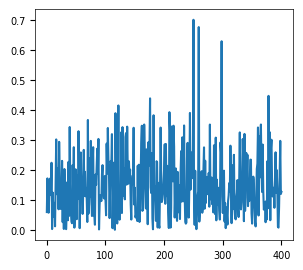

In [18]:
plt.plot(np.sqrt(np.square(E_fit - E_tosim)))
print(np.sum(np.sqrt(np.square(E_fit - E_tosim))))